# 4. Tutorial 4

**Course:** Power Electronics Devices and Components  

## 4.1. Tail-current and switching-energy map

MOSFET switching study with the simplified gate-charge model.

Following parameters are given:
- $V_\mathrm{DC} = 600~\mathrm{V}$
- $I_\mathrm{tail,0} = 10~\mathrm{A}$
- $\tau_\mathrm{PT} = 0.3~\mathrm{\mu s}$
- $\tau_\mathrm{NPT} = 0.8~\mathrm{\mu s}$

The simplified gate-charge model of  the IGBT  for turn-off current as two segments:
- Fast fall from $I_\mathrm{C} = 40~\mathrm{A}$ to $I_\mathrm{tail,0} = 10~\mathrm{A}$ over $100~\mathrm{ns}$
- Tail current  according $i_\mathrm{tail}(t) = I_\mathrm{tail,0} \cdot e^{-t/\tau}$

4.1.1 Import necessary modules (numpy as np and matplotlib.pyplot as plt) and add constant variables for the constant values.

4.1.2 Create a function 'calculate_switch_off_current' with input parameter $t$ (time point array), which calculates the switch off current according the two tail segments.
(Hint: Use a for-loop over the time and distinguish the two segments according the calculated current.)

4.1.3 Plot $i_\mathrm{tail}(t)$ in range $t=0 \ldots 5~\mathrm{\mu s}$ for the PT and NPT case.

4.1.4 Create a function with input parameter $i_\mathrm{tail}(t)$, which compute compute the tail-energy contribution according
$$E_\mathrm{tail} = V_\mathrm{DC} \int i_\mathrm{tail}(t) dt.$$

4.1.5 Compare the total turn-off energy for PT and NPT.

4.1.6 Explain how lifetime and drift-region structure shape the result.

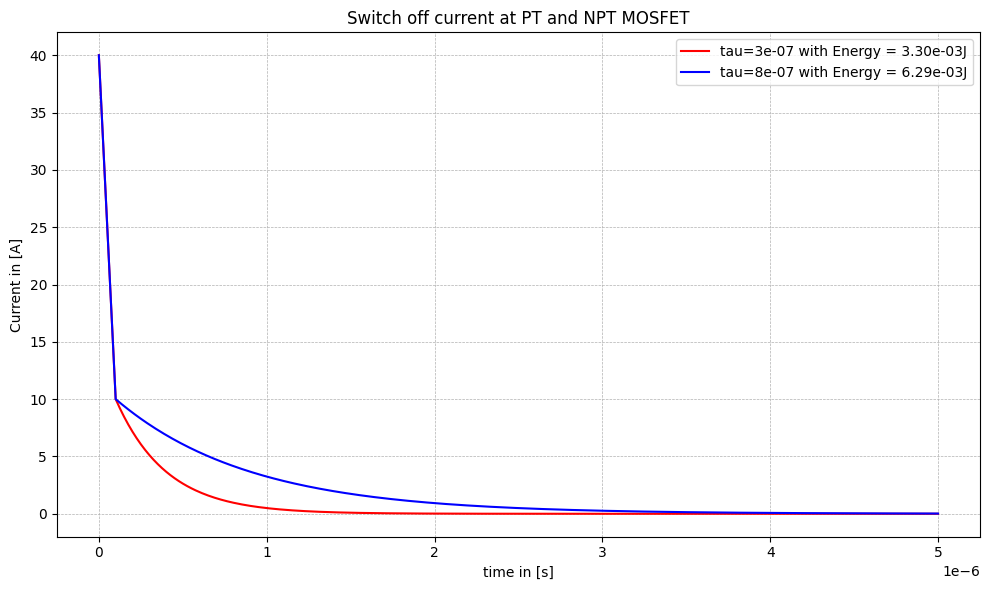

In [1]:
# Subtask 4.1.1 Import necessary modules (numpy as np and matplotlib.pyplot as plt) and add constant variables for the constant values.

import numpy as np
import matplotlib.pyplot as plt

# Create color list and marker list
color_list = ['red', 'blue', 'green', 'orange', 'black', 'cyan', 'magenta', 'purple']
marker_list=['o', '.', '+', '_', '*', 's', 'D', '^', 'v', '<', '>', 'p', 'h', 'H', 'x', 'D', 'd', 'P', 'X']


# ---------------------------------------------------------------------
# Fixed constants for the tutorial
# ---------------------------------------------------------------------
V_DC = 600        # 600V
I_tail_0 = 10     # 10A
tau_PT = 3e-7    # 0.3us
tau_NPT = 8e-7   # 0.8us
tau_list = [tau_PT, tau_NPT]

# 2 Sections: Fast fall down and exponential function tail:
I_ch = 40             # 40A
t_fall = 100e-9       # 100ns

# t-range is about 5 tau = 5us
t_range  = np.linspace(0, 5e-6, 400)        # Unit seconds

# Subtask 4.1.2 Create a function 'calculate_switch_off_current' with input parameter $t$ (time point array), which calculates the switch off current according the two tail segments.
def get_current_wave_form(act_t_range, tau):
    # Separate fall and tail range from input time vector
    t_fall_range = act_t_range[act_t_range<=t_fall]
    t_tail_range = act_t_range[act_t_range>t_fall]
    # Start of exponential function: Shift by minimal value
    t_tail_range = t_tail_range - t_tail_range.min()
    # Calculate foll slope
    m_fall = (I_tail_0 - I_ch) / t_fall
    I_fall = I_ch + m_fall * t_fall_range
    I_tail = I_tail_0 * np.exp(- t_tail_range / tau)
    I_t = np.concatenate((I_fall, I_tail), axis=0)
    return I_t

# Subtask  4.1.4 Create a function with input parameter $i_\mathrm{tail}(t)$, which compute compute the tail-energy contribution according
def calculate_energy(act_I, act_t):
    # Integal (according trapetz rule)
    E = np.trapezoid(V_DC * act_I, act_t)
    return E

if __name__ == "__main__":
    # Subtask 4.1.3 Plot i_tail(t) in range t=0...5us for the PT and NPT case.

    E_list = []

    # Generate the plot
    plt.figure(figsize=(10, 6))
    for i, act_tau in enumerate(tau_list):
        # Calculate i_tail
        I_t = get_current_wave_form(t_range, act_tau)
        # Calculate Energy
        E = calculate_energy(I_t, t_range)
        # Create legend per result and display Energy
        text=f"tau={act_tau} with Energy = {E:.2e}J"
        # plt.plot(t_range, I_t, label=text, color=color_list[i], marker=marker_list[i])
        plt.plot(t_range, I_t, label=text, color=color_list[i])


    plt.xlabel("time in [s]")
    plt.ylabel("Current in [A]")
    plt.title("Switch off current at PT and NPT MOSFET")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4.2. Conceptual SOA of an IGBT

This task is based on the lecture figure of the IGBT safe operating areas (FBSOA and RBSOA).

### Why this tutorial matters
The SOA of a power semiconductor is not defined only by maximum current and maximum voltage separately.  
It is defined by combinations of current and voltage that are safe under:
- forward conduction,
- pulsed operation,
- and turn-off.

This task helps students visualize:
- why the short-pulse FBSOA is larger than the DC FBSOA,
- and why the RBSOA becomes smaller when the reapplied \(dv_{CE}/dt\) increases.

### Fixed values for this tutorial
Use the following assumed tutorial values:
- $V_\mathrm{max} = 1200~\mathrm{V}$.
- $I_\mathrm{max} = 120~\mathrm{A}$.


For FBSOA, use the constant-power limits:
- $P_\mathrm{DC} = 24 ~\mathrm{kW}$.
- $P_\mathrm{0.1ms} = 48 ~\mathrm{kW}$ for the time of $0.1ms$.
- $P_\mathrm{10\mu s} = 90 ~\mathrm{kW}$ for the time of $10\mu s$.

### Important note
The lecture figure gives the **shape** of the RBSOA, but it does not provide an exact numerical law.
Therefore, in this tutorial, the RBSOA is plotted as a **conceptual construction** that reproduces the qualitative behavior seen in the lecture:
- same current limit,
- same voltage limit,
- and an upper-right clipping region that becomes more restrictive as the reapplied \(dv_{CE}/dt\) increases.

### Student tasks

#### Part A — Forward-bias SOA (FBSOA)
4.2.1 Add constant variables for \(V_{\max}\), \(I_{\max}\), and the three power limits.

4.2.2 Create a function `get_FBSOA(t_max)` that calculates the current boundary using
\[
I_C(V_{CE}) = \min\left(I_{\max}, \frac{P}{V_{CE}}\right)
\]
where the power limit \(P\) depends on the selected pulse duration.

4.2.3 Plot the FBSOA for:
- DC,
- $0.1~\mathrm{ms}$,
- $10~\mathrm{\mu s}$.

4.2.4 Explain why the short-pulse limit lies above the DC limit.

4.2.5 Choose three operating points from the FBSOA graph:
- two safe,
- one unsafe or borderline,
and justify your answer.

#### Part B — Reverse-bias SOA (RBSOA)
4.2.6 Plot a **conceptual RBSOA** for three reapplied voltage slopes:
\[
\frac{dv_{CE}}{dt} = 1000,\ 2000,\ 3000~\mathrm{V/\mu s}
\]

Use the following modeling assumption for the tutorial:
- all clipping boundaries are **parallel**,
- they begin to cut the upper-right corner of the SOA at high voltage,
- and larger \(dv_{CE}/dt\) shifts the clipping line downward.

4.2.7 Choose three operating points from the RBSOA graph:
- two safe,
- one unsafe or borderline,
and justify your answer.

4.2.8 Explain physically why the RBSOA becomes smaller as the reapplied $(dv_{CE}/dt)$ increases.

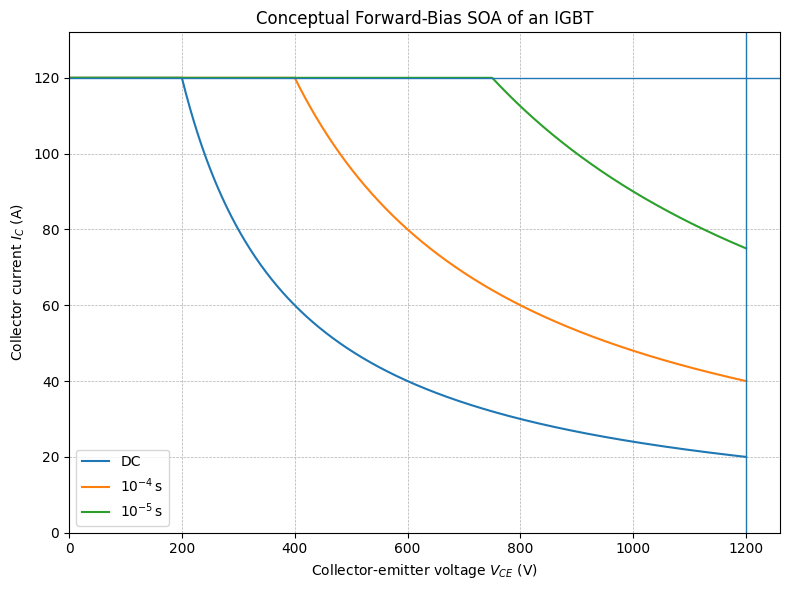

In [ ]:
# -------------------------------
# Assumed limits for tutorial use
# -------------------------------
Vmax = 1200.0   # V
Imax = 120.0    # A
 
# Define 100 voltage samples from 0 to Vmax 
V = np.linspace(0.01, Vmax, 1000)
 
# ---------------------------------------
# Forward-bias SOA (FBSOA) - thermal lines
# ---------------------------------------
# Constant-power style approximations
P_dc   = 2.4e4   # W
P_1e4  = 4.8e4   # W for 1e-4 s
P_1e5  = 9.0e4   # W for 1e-5 s
 
t_1em4 = 1e-4
t_1em5 = 1e-5
 
# Subtask  4.2.2 Create a function 'get_FBSOA' with input parameter $t_\mathrm{max}
def get_FBSOA(act_t):
    # Separate by time ranges
    if act_t <= t_1em5:
        P_act = P_1e5
    elif act_t <= t_1em4:
        P_act = P_1e4
    else:
        P_act = P_dc

    # Calculate the current
    i=np.minimum(Imax, P_act / V)
    return i

if __name__ == "__main__":

    # Subtask 4.2.3 Plot the FBSOA for the 3 time values.
    # Subtask 4.2.5 Mark three sample operating points on the FBSOA plot.

    plt.figure(figsize=(8, 6))
    # Calculate the currents
    I_dc = get_FBSOA(1)
    I_1e4 = get_FBSOA(t_1em4)
    I_1e5 = get_FBSOA(t_1em5)

    plt.plot(V, I_dc,  label='DC')
    plt.plot(V, I_1e4, label=r'$10^{-4}\,\mathrm{s}$')
    plt.plot(V, I_1e5, label=r'$10^{-5}\,\mathrm{s}$')
    
    # Optionally maximum current and voltage can be insert to the plot
    plt.axhline(Imax, linewidth=1)
    plt.axvline(Vmax, linewidth=1)
    
    plt.xlim(0, Vmax*1.05)
    plt.ylim(0, Imax*1.1)
    plt.xlabel(r'Collector-emitter voltage $V_{CE}$ (V)')
    plt.ylabel(r'Collector current $I_C$ (A)')
    plt.title('Conceptual Forward-Bias SOA of an IGBT')
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()



Subtask 4.2.4:  Due to the temperature capacity of the material the heating takes some time, before you exceed the maximum temperature. The shorter the duration of the power loss, the higher the permissible power loss. However, the maximum permissible current and voltage must not be exceeded.

Subtask 4.2.5 
- 100A, 800V for $8 \mathrm{\mu s}$: Maximum current and voltage limit are not exceeded and you are within the FBSOA-Range.
- 100A, 600V for 1 ms :  Maximum current and voltage limit are not exceeded, but you are outside of the FBSOA-Range.
- 20A, 1000V for 1h: Maximum current and voltage limit are not exceeded and you are within the FBSOA-Range.

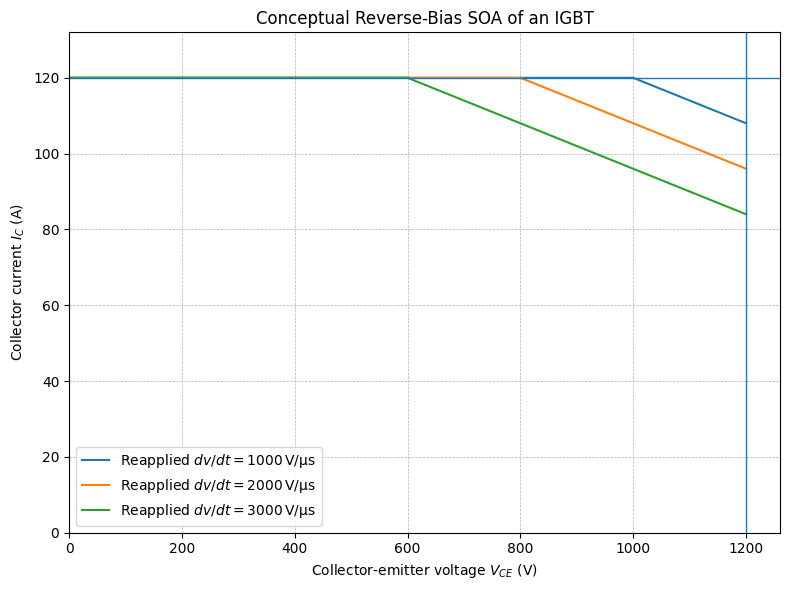

In [5]:

# Subtask 4.2.6 Plot three RBSOA boundaries corresponding to reapplied

# ---------------------------------------
# Reverse-bias SOA (RBSOA) clipping lines
# ---------------------------------------
# Piecewise linear upper-right clipping, tutorial-style
m_clip = 0.06  # common slope for all lines, tutorial assumption

I_rbs_1000 = np.minimum(Imax, np.maximum(0, Imax - m_clip*(V - 1000)))
I_rbs_2000 = np.minimum(Imax, np.maximum(0, Imax - m_clip*(V - 800)))
I_rbs_3000 = np.minimum(Imax, np.maximum(0, Imax - m_clip*(V - 600)))


if __name__ == "__main__":
 
    # -------------------------------
    # Plot 2: RBSOA
    # -------------------------------
    plt.figure(figsize=(8, 6))
    plt.plot(V, I_rbs_1000, label=r'Reapplied $dv/dt = 1000\,\mathrm{V/\mu s}$')
    plt.plot(V, I_rbs_2000, label=r'Reapplied $dv/dt = 2000\,\mathrm{V/\mu s}$')
    plt.plot(V, I_rbs_3000, label=r'Reapplied $dv/dt = 3000\,\mathrm{V/\mu s}$')
    
     # Optionally maximum current and voltage can be insert to the plot
    plt.axhline(Imax, linewidth=1)
    plt.axvline(Vmax, linewidth=1)
    
    plt.xlim(0, Vmax*1.05)
    plt.ylim(0, Imax*1.1)
    plt.xlabel(r'Collector-emitter voltage $V_{CE}$ (V)')
    plt.ylabel(r'Collector current $I_C$ (A)')
    plt.title('Conceptual Reverse-Bias SOA of an IGBT')
    plt.grid(True, linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

Subtask 4.2.7:   RBSOA: 
- 110A, 1000V at 1000 $V/\mathrm{\mu s}$: Maximum current and voltage limit are not exceeded and you are within the RBSOA-Range.
- 100A, 1000V at 3000 $V/\mathrm{\mu s}$: Maximum current and voltage limit are not exceeded, but you are outside of the RBSOA-Range.
- 100A, 1100V at 2000 $V/\mathrm{\mu s}$: Maximum current and voltage limit are not exceeded and you are within the RBSOA-Range.

Subtask 4.2.8 Explain physically why the RBSOA becomes smaller as the reapplied $(dv_{CE}/dt)$ increases.
- The RBSOA shrinks with increasing reapplied $(dv_{CE}/dt)$ because a faster voltage rise during turn-off produces larger capacitive and internal transient currents, which increase the risk of parasitic thyristor latch-up. Therefore, the device can safely turn off only smaller current levels at high voltage when $(dv_{CE}/dt)$ is larger.